# Homework 4

## Follow These Steps Before Submitting
Once you are finished, ensure to complete the following steps.

1.  Restart your kernel by clicking 'Kernel' > 'Restart & Run All'.

2.  Fix any errors which result from this.

3.  Repeat steps 1. and 2. until your notebook runs without errors.

4.  Submit your completed notebook to OWL by the deadline.


# 1. Wisconsin Breast Cancer Dataset

In this assignment, you will use a modified version of the well-known Wisconsin Breast Cancer dataset. We want to predict if a patient has a malignant or benign tumour. The features in the dataset are described below:


**Cl.thickness**:	Clump Thickness

**Cell.size**:	Uniformity of Cell Size

**Cell.shape**:	Uniformity of Cell Shape

**Marg.adhesion**:	Marginal Adhesion

**Epith.c.size**:	Single Epithelial Cell Size

**Bare.nuclei**:	Bare Nuclei

**Bl.cromatin**:	Bland Chromatin

**Normal.nucleoli**:	Normal Nucleoli

**Mitoses**:	Mitoses

**Age**: Age

**Class**: 1 if malignant, 0 if benign

In [1]:
# Package import
import numpy as np

# Scikit-learn imports
from sklearn.model_selection import train_test_split, cross_validate, RepeatedKFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# Data management imports
import pandas as pd
import polars as pl

# Plotting imports
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [2]:
# Uncomment the line below if you are using Google colab
!gdown https://drive.google.com/uc?id=12Y-PdpmPLInGGBvFAn_G3eCfXrRETvuF

Downloading...
From: https://drive.google.com/uc?id=12Y-PdpmPLInGGBvFAn_G3eCfXrRETvuF
To: /content/Breast Cancer Data.csv
100% 17.4k/17.4k [00:00<00:00, 30.7MB/s]


1. Read the CSV file using Polars and store it. Use "null_values=['NA']". Show summary statistics for the dataset. What is the baseline accuracy for a model?

In [3]:
df=pl.read_csv('Breast Cancer Data.csv',null_values=['NA'])
df.head()

Cl.thickness,Cell.size,Cell.shape,Marg.adhesion,Epith.c.size,Bare.nuclei,Bl.cromatin,Normal.nucleoli,Mitoses,Class,Age
i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
5,1,1,1,2,1,3,1,1,0,59
5,4,4,5,7,10,3,2,1,0,48
3,null,null,1,2,2,3,1,1,0,64
6,8,8,1,3,4,3,7,1,0,44
4,1,1,3,2,1,3,1,1,0,49


In [4]:
df.describe()

statistic,Cl.thickness,Cell.size,Cell.shape,Marg.adhesion,Epith.c.size,Bare.nuclei,Bl.cromatin,Normal.nucleoli,Mitoses,Class,Age
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",696.0,694.0,694.0,699.0,699.0,683.0,699.0,699.0,699.0,699.0,699.0
"""null_count""",3.0,5.0,5.0,0.0,0.0,16.0,0.0,0.0,0.0,0.0,0.0
"""mean""",4.426724,3.136888,3.208934,2.806867,3.216023,3.544656,3.437768,2.866953,1.569385,0.344778,50.100143
"""std""",2.815748,3.053632,2.973356,2.855379,2.2143,3.643857,2.438364,3.053634,1.619803,0.475636,17.97766
"""min""",1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,3.0
"""25%""",2.0,1.0,1.0,1.0,2.0,1.0,2.0,1.0,1.0,0.0,38.0
"""50%""",4.0,1.0,1.0,1.0,2.0,1.0,3.0,1.0,1.0,0.0,50.0
"""75%""",6.0,5.0,5.0,4.0,4.0,6.0,5.0,4.0,1.0,1.0,62.0
"""max""",10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,9.0,1.0,105.0


In [5]:
positive = df.select('Class').mean().to_numpy().item()
print(f"The positive rate of the sample is {positive*100:.2f}%")

# Now compute the baseline accuracy
baselineacc = 1 - positive
print(f"The baseline accuracy of the problem is {baselineacc*100:.2f}%")

The positive rate of the sample is 34.48%
The baseline accuracy of the problem is 65.52%


2. Assume that we are only interested in studying people aged 100 or less. Remove anyone with ages larger than that. (Note that this slightly changes your baseline accuracy.)

In [6]:
df=df.filter(pl.col('Age')<=100)
df.describe()

statistic,Cl.thickness,Cell.size,Cell.shape,Marg.adhesion,Epith.c.size,Bare.nuclei,Bl.cromatin,Normal.nucleoli,Mitoses,Class,Age
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",694.0,692.0,692.0,697.0,697.0,681.0,697.0,697.0,697.0,697.0,697.0
"""null_count""",3.0,5.0,5.0,0.0,0.0,16.0,0.0,0.0,0.0,0.0,0.0
"""mean""",4.419308,3.130058,3.202312,2.803443,3.208034,3.538913,3.43472,2.870875,1.571019,0.344333,49.942611
"""std""",2.811793,3.04579,2.965229,2.854235,2.202022,3.639493,2.433979,3.05702,1.62184,0.475491,17.760609
"""min""",1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,3.0
"""25%""",2.0,1.0,1.0,1.0,2.0,1.0,2.0,1.0,1.0,0.0,38.0
"""50%""",4.0,1.0,1.0,1.0,2.0,1.0,3.0,1.0,1.0,0.0,50.0
"""75%""",6.0,5.0,5.0,4.0,4.0,6.0,5.0,4.0,1.0,1.0,62.0
"""max""",10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,9.0,1.0,99.0


In [7]:
positive2 = df.select('Class').mean().to_numpy().item()
baselineacc2 = 1 - positive2
print(f"The baseline accuracy is now {baselineacc2*100:.2f}%")

The baseline accuracy is now 65.57%


3. Replace the missing values in the dataset using the median of the corresponding predictor.

In [8]:
numeric_columns = [col for col in df.columns if df[col].dtype in [pl.Float64, pl.Int64]]
df = df.with_columns([df[col].fill_null(df[col].median()) for col in numeric_columns])
df.describe()

statistic,Cl.thickness,Cell.size,Cell.shape,Marg.adhesion,Epith.c.size,Bare.nuclei,Bl.cromatin,Normal.nucleoli,Mitoses,Class,Age
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",697.0,697.0,697.0,697.0,697.0,697.0,697.0,697.0,697.0,697.0,697.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",4.417504,3.114778,3.186514,2.803443,3.208034,3.480631,3.43472,2.870875,1.571019,0.344333,49.942611
"""std""",2.805861,3.040157,2.960408,2.854235,2.202022,3.617484,2.433979,3.05702,1.62184,0.475491,17.760609
"""min""",1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,3.0
"""25%""",2.0,1.0,1.0,1.0,2.0,1.0,2.0,1.0,1.0,0.0,38.0
"""50%""",4.0,1.0,1.0,1.0,2.0,1.0,3.0,1.0,1.0,0.0,50.0
"""75%""",6.0,5.0,5.0,4.0,4.0,5.0,5.0,4.0,1.0,1.0,62.0
"""max""",10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,9.0,1.0,99.0


4. Create a training and testing dataset. Reserve 30% of the data for testing and stratify the split based on the outcome. Use a random state of 0.

In [9]:
Xtrain, Xtest, ytrain, ytest = train_test_split(df.drop('Class'), df['Class'], test_size=0.3, stratify=df['Class'], random_state=0)
Xtrain.head()

Cl.thickness,Cell.size,Cell.shape,Marg.adhesion,Epith.c.size,Bare.nuclei,Bl.cromatin,Normal.nucleoli,Mitoses,Age
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
8.0,7.0,5.0,10.0,7.0,9.0,5.0,5.0,4.0,56.0
1.0,1.0,1.0,1.0,2.0,1.0,3.0,1.0,1.0,71.0
10.0,5.0,10.0,3.0,5.0,8.0,7.0,8.0,3.0,75.0
3.0,1.0,1.0,2.0,3.0,4.0,1.0,1.0,1.0,38.0
1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,15.0


5. Using all potential predictors, train a logistic regression model to predict if a patient has the condition. Remember to standardize the predictors. Use the following arguments: solver='lbfgs', penalty=None, max_iter=10000, verbose=1, random_state=0, and n_jobs=-1.

In [10]:
features_to_transform = [
    'Cl.thickness', 'Cell.size', 'Cell.shape',
    'Marg.adhesion', 'Epith.c.size', 'Bare.nuclei',
    'Bl.cromatin', 'Normal.nucleoli', 'Mitoses', 'Age'
]

# Ensure no accidental spaces or tab characters in column names
features_to_transform = [col.strip() for col in features_to_transform]

transform_numbers = ColumnTransformer(
    [('scaler', StandardScaler(), features_to_transform)],
    remainder='passthrough',
    verbose_feature_names_out=False
)

logit_pipe = Pipeline([
    ('scaler', transform_numbers),
    ('logistic_regression', LogisticRegression(
        solver='lbfgs',
        penalty=None,
        max_iter=10000,
        verbose=1,
        random_state=0,
        n_jobs=-1,
        class_weight='balanced'
    ))
])

logit_pipe.fit(Xtrain, ytrain.to_numpy().ravel())

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Pipeline(steps=[('scaler',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scaler', StandardScaler(),
                                                  ['Cl.thickness', 'Cell.size',
                                                   'Cell.shape',
                                                   'Marg.adhesion',
                                                   'Epith.c.size',
                                                   'Bare.nuclei', 'Bl.cromatin',
                                                   'Normal.nucleoli', 'Mitoses',
                                                   'Age'])],
                                   verbose_feature_names_out=False)),
                ('logistic_regression',
                 LogisticRegression(class_weight='balanced', max_iter=10000,
                                    n_jobs=-1, penalty=None, random_state=0,
                                    verbose=1))])

6. Compute the accuracy and AUC of your model on the test set.

In [11]:
accuracy = logit_pipe.score(Xtest, ytest.to_numpy().ravel())
yprob = logit_pipe.predict_proba(Xtest)[:, 1]

ypred = logit_pipe.predict(Xtest)

auc = roc_auc_score(ytest, yprob)

print(f"The accuracy of the model is {accuracy*100:.2f}%")
print(f"The AUC of the model is {auc:.3f}")

The accuracy of the model is 97.14%
The AUC of the model is 0.996


7. Without estimates of the uncertainty of the performance metrics, it can be hard to make definitive conclusions about the performance of the model. Compute 95% confidence intervals for the accuracy and AUC using bootstrapping with 1000 replicates. Interpret your results.

In [12]:
n_bootstraps = 1000
bootstrapped_accuracy = np.zeros(n_bootstraps)
bootstrapped_auc = np.zeros(n_bootstraps)

In [13]:
for i in range(n_bootstraps):
    # Get the indices for the bootstrap sample
    idx = np.random.choice(len(ytest), len(ytest), replace=True)

    # Get the accuracy of the bootstrap sample
    bootstrapped_accuracy[i] = accuracy_score(ytest.to_pandas().iloc[idx], ypred[idx])

    # Get the AUC of the bootstrap sample
    bootstrapped_auc[i] = roc_auc_score(ytest.to_pandas().iloc[idx], yprob[idx])

# Get the differences between the bootstrapped values and the original values
accuracy_diff = bootstrapped_accuracy - accuracy
auc_diff = bootstrapped_auc - auc

# Calculate the 95% confidence interval for the accuracy and AUC
accuracy_ci = np.percentile(accuracy_diff, [2.5, 97.5])
auc_ci = np.percentile(auc_diff, [2.5, 97.5])

# Show the ci bounds
print(accuracy_ci)
print(auc_ci)

[-0.02380952  0.01904762]
[-0.0057675  0.0032366]


In [14]:
# Print the results. Centre the values around the original values.
print(f"The 95% confidence interval for the accuracy is [{(accuracy - accuracy_ci[1])*100:.2f}%, {(accuracy - accuracy_ci[0])*100:.2f}%]")
print(f"The 95% confidence interval for the AUC is [{(auc - auc_ci[1]):.2f}, {(auc - auc_ci[0]):.2f}]")

The 95% confidence interval for the accuracy is [95.24%, 99.52%]
The 95% confidence interval for the AUC is [0.99, 1.00]


8. Plot the distribution of the accuracy and AUC using histograms. Make sure to provide a title and axes labels for your plots. Add a red vertical line representing the mean of accuracy and AUC.

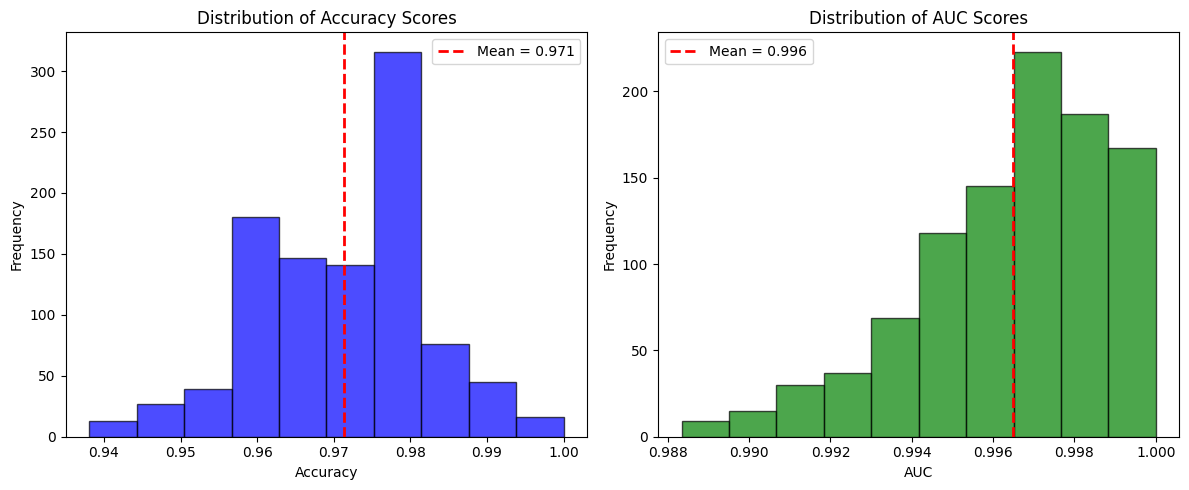

In [15]:
mean_accuracy = np.mean(bootstrapped_accuracy)
mean_auc = np.mean(bootstrapped_auc)

# Create the Accuracy histogram
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(bootstrapped_accuracy, bins=10, color="blue", alpha=0.7, edgecolor="black")
plt.axvline(mean_accuracy, color="red", linestyle="dashed", linewidth=2, label=f"Mean = {mean_accuracy:.3f}")
plt.title("Distribution of Accuracy Scores")
plt.xlabel("Accuracy")
plt.ylabel("Frequency")
plt.legend()

# Create the AUC histogram
plt.subplot(1, 2, 2)
plt.hist(bootstrapped_auc, bins=10, color="green", alpha=0.7, edgecolor="black")
plt.axvline(mean_auc, color="red", linestyle="dashed", linewidth=2, label=f"Mean = {mean_auc:.3f}")
plt.title("Distribution of AUC Scores")
plt.xlabel("AUC")
plt.ylabel("Frequency")
plt.legend()

# Show the plots
plt.tight_layout()
plt.show()

9. Compute 95% confidence intervals for the accuracy and AUC using repeated cross-validation. Use 10 splits and 100 repetitions with a random state of 0. Compare your results to what you obtained using bootstrapping. Which method provides better confidence intervals in this case?

In [16]:
# Redefine the pipeline to eliminate verbose and make it sequential
logit_pipe = Pipeline([
    ('scaler', transform_numbers),
    ('logistic_regression', LogisticRegression(solver='lbfgs',
                                               penalty = None,
                                               max_iter=10000,
                                               verbose=0,
                                               random_state=0,
                                               n_jobs=1,
                                               class_weight='balanced'))
])

# Create the RepeatedKFold object for 10-by-10
cv = RepeatedKFold(n_splits=10, n_repeats=10, random_state=20252201)

# Perform cross-validation
cv_results = cross_validate(logit_pipe, # The pipeline to cross-validate
                            df.drop('Class'), # The features
                            df.select('Class').to_numpy().ravel(), # The target
                            cv=cv, # The cross-validation object we created
                            scoring=['accuracy', 'roc_auc'], # The metrics we want to calculate
                            return_estimator=True, # Return the estimator for each fold. Useful for calculating parameter uncertainty.
                            n_jobs=-1 # Use all available cores
                            )

In [17]:
# Get the accuracy and AUC scores
accuracy_scores = cv_results['test_accuracy']
auc_scores = cv_results['test_roc_auc']

# Calculate the mean and standard deviation of the accuracy and AUC scores
accuracy_mean = accuracy_scores.mean()
accuracy_std = accuracy_scores.std()
auc_mean = auc_scores.mean()
auc_std = auc_scores.std()

# Print the results
print(f"The CI for the model accuracy is [{(accuracy_mean - 1.96*accuracy_std)*100:.2f}%, {(accuracy_mean + 1.96*accuracy_std)*100:.2f}%]")
print(f"The CI for the AUC of the model is [{auc_mean-1.96*auc_std:.3f},{auc_mean+1.96*auc_std:.3f}]")
print(f"The mean CV accuracy value is {accuracy_mean*100:.2f}%")
print(f"The mean CV AUC value is {auc_mean:.3f}")

The CI for the model accuracy is [92.20%, 101.01%]
The CI for the AUC of the model is [0.981,1.007]
The mean CV accuracy value is 96.60%
The mean CV AUC value is 0.994


**Note the upper bound should not increase beyond 100, this is due to the high variance.**

10. Using your cross-validation results, compute a 95% confidence interval for each coefficient in the model. Which feature(s) might you remove based on this?

In [18]:
# Get feature names from the pipeline
feature_names = transform_numbers.get_feature_names_out()

# Extract coefficients from each cross-validation fold
all_coefficients = np.array([estimator.named_steps["logistic_regression"].coef_.flatten() for estimator in cv_results["estimator"]])

# Compute mean and 95% confidence intervals for each coefficient
coef_means = np.mean(all_coefficients, axis=0)
coef_ci = np.percentile(all_coefficients, [2.5, 97.5], axis=0)  # 95% CI

# Store results in a DataFrame for clarity
coef_summary = pd.DataFrame({
    "Feature": feature_names,
    "Mean Coefficient": coef_means,
    "Lower 95% CI": coef_ci[0],
    "Upper 95% CI": coef_ci[1]
})

# Display coefficient summary
display(coef_summary)  # This works in Jupyter Notebook without extra imports


,Feature,Mean Coefficient,Lower 95% CI,Upper 95% CI
0,Cl.thickness,1.661464,1.423439,2.263165
1,Cell.size,0.028724,-0.367168,0.450870
2,Cell.shape,1.026798,0.703692,1.501570
3,Marg.adhesion,0.826801,0.462521,1.233554
4,Epith.c.size,0.047078,-0.453809,0.261863
5,Bare.nuclei,1.748328,1.481232,2.135835
6,Bl.cromatin,1.057143,0.696512,1.458664
7,Normal.nucleoli,0.538676,0.283382,0.850529
8,Mitoses,1.009689,0.747862,1.413027
9,Age,0.323251,0.066679,0.683931


Remove Cellsize, and Epith.c.size as the confidence is across negative and poisitive

11. Fit your logistic regression model like before but remove the feature(s) you indentified in Q10. Plot the ROC curve of the model over the test set and annotate it with the AUC of the model.

In [19]:
Xtrain2, Xtest2, ytrain2, ytest2 = train_test_split(df.drop('Class','Cell.size','Epith.c.size'), df['Class'], test_size=0.3, stratify=df['Class'], random_state=0)

Xtrain2.head()

features_to_transform2 = [
    'Cl.thickness', 'Cell.shape',
    'Marg.adhesion', 'Bare.nuclei',
    'Bl.cromatin', 'Normal.nucleoli', 'Mitoses', 'Age'
]

# Ensure no accidental spaces or tab characters in column names
features_to_transform2 = [col.strip() for col in features_to_transform2]

transform_numbers2 = ColumnTransformer(
    [('scaler', StandardScaler(), features_to_transform2)],
    remainder='passthrough',
    verbose_feature_names_out=False
)

logit_pipe2 = Pipeline([
    ('scaler', transform_numbers2),
    ('logistic_regression', LogisticRegression(
        solver='lbfgs',
        penalty=None,
        max_iter=10000,
        verbose=1,
        random_state=0,
        n_jobs=-1,
        class_weight='balanced'
    ))
])

logit_pipe2.fit(Xtrain2, ytrain2.to_numpy().ravel())

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Pipeline(steps=[('scaler',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scaler', StandardScaler(),
                                                  ['Cl.thickness', 'Cell.shape',
                                                   'Marg.adhesion',
                                                   'Bare.nuclei', 'Bl.cromatin',
                                                   'Normal.nucleoli', 'Mitoses',
                                                   'Age'])],
                                   verbose_feature_names_out=False)),
                ('logistic_regression',
                 LogisticRegression(class_weight='balanced', max_iter=10000,
                                    n_jobs=-1, penalty=None, random_state=0,
                                    verbose=1))])

In [20]:
accuracy = logit_pipe2.score(Xtest2, ytest2.to_numpy().ravel())
yprob2 = logit_pipe2.predict_proba(Xtest2)[:, 1]

ypred2 = logit_pipe2.predict(Xtest2)

auc = roc_auc_score(ytest2, yprob2)

print(f"The accuracy of the model is {accuracy*100:.2f}%")
print(f"The AUC of the model is {auc:.3f}")

The accuracy of the model is 97.62%
The AUC of the model is 0.997


[-0.97619048 -0.97619048]
[-0.9974839 -0.9974839]


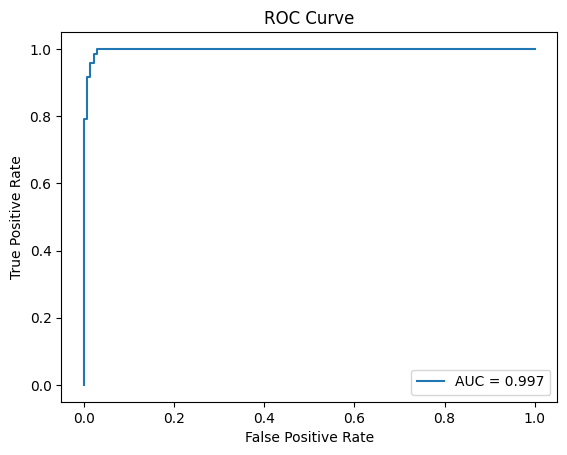

In [21]:
n_bootstraps = 1000
bootstrapped_accuracy2 = np.zeros(n_bootstraps)
bootstrapped_auc2 = np.zeros(n_bootstraps)
for i in range(n_bootstraps):
    # Get the indices for the bootstrap sample
    idx = np.random.choice(len(ytest2), len(ytest2), replace=True)

    # Get the accuracy of the bootstrap sample
    bootstrapped_accuracy[i] = accuracy_score(ytest2.to_pandas().iloc[idx], ypred2[idx])

    # Get the AUC of the bootstrap sample
    bootstrapped_auc[i] = roc_auc_score(ytest2.to_pandas().iloc[idx], yprob2[idx])

# Get the differences between the bootstrapped values and the original values
accuracy_diff = bootstrapped_accuracy2 - accuracy
auc_diff = bootstrapped_auc2 - auc

# Calculate the 95% confidence interval for the accuracy and AUC
accuracy_ci = np.percentile(accuracy_diff, [2.5, 97.5])
auc_ci = np.percentile(auc_diff, [2.5, 97.5])

# Show the ci bounds
print(accuracy_ci)
print(auc_ci)

mean_accuracy = np.mean(bootstrapped_accuracy)
mean_auc = np.mean(bootstrapped_auc)
ytest2_pred = logit_pipe2.predict_proba(Xtest2)


# Create the Accuracy histogram
fpr, tpr, thresholds = roc_curve(y_true=ytest2, y_score=ytest2_pred[:,1])

# Save the AUC in a variable to display it. Round it first
auc = np.round(roc_auc_score(y_true=ytest2, y_score=ytest2_pred[:,1]),
               decimals = 3)
plt.plot(fpr,tpr,label=f"AUC = {auc:.3f}")
plt.legend(loc=4)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

12. Calculate the uncertainty for the prediction of the first testing patient.  Plot a histogram of the different predictions. Give the plot a title and axes labels. Add a red vertical line representing the mean of the predictions.

Hint: If you need to stack a list of arrays, you can use [np.hstack(list)](https://numpy.org/doc/stable/reference/generated/numpy.hstack.html).

In [32]:
first_patient_preds = []
first_patient_Xtest = Xtest.with_row_index().filter(pl.col("index") == 0).drop("index")
for fold_model in cv_results['estimator']:
  first_patient_preds.append(fold_model.predict_proba(first_patient_Xtest)[:, 1])
first_patient_preds = np.hstack(first_patient_preds)
first_patient_mean = np.mean(first_patient_preds)
first_patient_std = np.std(first_patient_preds)
first_patient_LB = first_patient_mean - 1.96*first_patient_std
first_patient_UB = first_patient_mean + 1.96*first_patient_std
print(f"The CI for the predicted probability of the positive class for the first testing patient is [{first_patient_LB:.3f}, {first_patient_UB:.3f}]")

The CI for the predicted probability of the positive class for the first testing patient is [0.008, 0.016]


Mean prediction for the first testing patient: 0.013193468991151274
Prediction uncertainty (std. dev.): 0.0022616123304397685


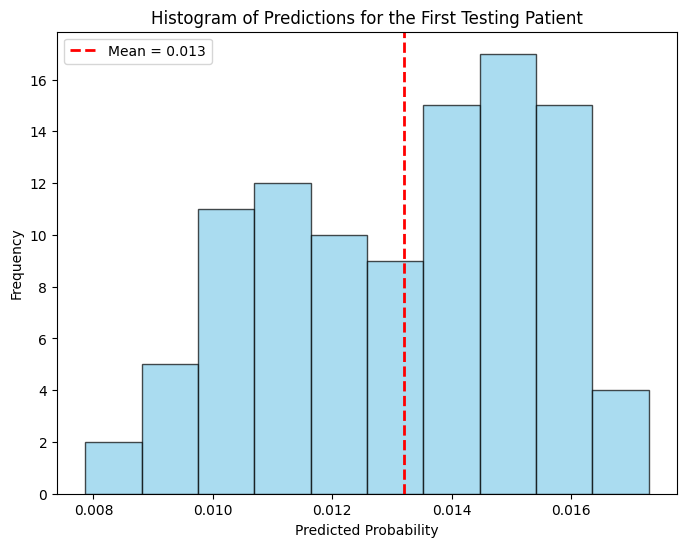

In [31]:
cv = RepeatedKFold(n_splits=10, n_repeats=10, random_state=20252201)

cv_results_new = cross_validate(
    logit_pipe2,
    Xtrain2,  # Use the new features (without 'Cell.size' and 'Epith.c.size')
    ytrain2.to_numpy().ravel(),
    cv=cv,
    scoring=['accuracy', 'roc_auc'],
    return_estimator=True,
    n_jobs=-1
)
first_patient_new = Xtest2.head(1).to_pandas()
predictions = np.array([
    estimator.predict_proba(first_patient_new)[:, 1][0]
    for estimator in cv_results_new["estimator"]
])

mean_prediction = np.mean(predictions)
uncertainty = np.std(predictions)

print("Mean prediction for the first testing patient:", mean_prediction)
print("Prediction uncertainty (std. dev.):", uncertainty)

plt.figure(figsize=(8, 6))
plt.hist(predictions, bins=10, color="skyblue", edgecolor="black", alpha=0.7)
plt.axvline(mean_prediction, color="red", linestyle="--", linewidth=2,
            label=f"Mean = {mean_prediction:.3f}")
plt.title("Histogram of Predictions for the First Testing Patient")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.legend()
plt.show()